<a href="https://colab.research.google.com/github/usman-stack-322/flyrank-ml-internship-v2/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/usman-stack-322/flyrank-ml-internship-v2/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Abstract

This project investigates which web pages should be prioritized for content refresh using observed search performance and opportunity signals. An anonymized dataset of 30,000 pages was used to build a binary classification model for identifying declining pages.

A Random Forest model using 38 features was evaluated with a time-aware 80/20 split. The model measured an F1 score of 0.837 on the test split, compared with 0.320 for the Week-4 baseline.

The results provide a stronger directional signal for prioritization in this dataset. The resulting action queue is intended for decision-support and human review, not as proof that refreshing a page will cause improved performance.


## 1. Question

**Research Question:**
Which pages should be prioritized for content refresh based on their observed search performance and opportunity signals?

**Decision Supported:**
The analysis supports prioritizing pages for human review and possible content refresh based on observed search performance and model-generated decline signals.

The output is intended for decision-support and prioritization. It does not establish that refreshing a page will cause improved performance.


In [17]:
# ============================================================
# CAPSTONE — Section 1: Question check
# ============================================================

research_question = (
    "Which pages should be prioritized for content refresh "
    "based on their observed search performance and opportunity signals?"
)

decision_supported = (
    "Prioritize pages for human review and possible content refresh "
    "using observed performance and model-generated decline signals."
)

print("RESEARCH QUESTION")
print("-" * 60)
print(research_question)

print("\nDECISION SUPPORTED")
print("-" * 60)
print(decision_supported)

print("\nUse:")
print("Decision-support and prioritization")

RESEARCH QUESTION
------------------------------------------------------------
Which pages should be prioritized for content refresh based on their observed search performance and opportunity signals?

DECISION SUPPORTED
------------------------------------------------------------
Prioritize pages for human review and possible content refresh using observed performance and model-generated decline signals.

Use:
Decision-support and prioritization


## 2. Data

This analysis uses the public-safe anonymized content-refresh dataset, `content_refresh_anonymized.csv`, from the FlyRank internship repository.

The dataset contains **30,000 rows** and was used to study observed search and content-performance signals.

The analysis uses search-performance, engagement, content, freshness, and competition-related fields. The final model uses **38 features**.

The target was derived from the observed `trend_direction` field. A page was labeled as declining when `trend_direction == "down"`.

For validation, the data was split in time order: the earlier **80% (24,000 rows)** was used for training and the later **20% (6,000 rows)** was used as the time-aware test set.

The analysis excludes identifying or client-specific fields such as `client_id` and `content_id` from the model features. The target and direct trend fields were also excluded from the final feature set to reduce leakage risk.

The analysis is limited to the available anonymized dataset and its observed measurement windows. No private client queries or identifying information are included in the paper.


In [18]:
# ============================================================
# CAPSTONE — SECTION 2: DATA
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# 1. Confirm the repository and dataset
# ------------------------------------------------------------

REPO_DIR = "/content/flyrank-ml-internship-v2"

DATA_PATH = os.path.join(
    REPO_DIR,
    "data",
    "raw",
    "content_refresh_anonymized.csv"
)

print("DATASET CHECK")
print("-" * 60)

print("Repository exists:", os.path.exists(REPO_DIR))
print("Dataset exists:", os.path.exists(DATA_PATH))

# Stop with a clear message if the dataset cannot be found.
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}"
    )

# ------------------------------------------------------------
# 2. Load dataset
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH)

print("Dataset path:", DATA_PATH)
print("Rows:", len(df))
print("Columns before target:", len(df.columns))

# ------------------------------------------------------------
# 3. Create the target
# ------------------------------------------------------------

df["is_declining_label"] = (
    df["trend_direction"] == "down"
).astype(int)

print("\nTARGET")
print("-" * 60)

print("Target name:", "is_declining_label")
print("Target created:", "is_declining_label" in df.columns)

print("\nTarget distribution:")
print(df["is_declining_label"].value_counts())

# ------------------------------------------------------------
# 4. Time-aware split
# ------------------------------------------------------------

split_point = int(len(df) * 0.80)

train_df = df.iloc[:split_point].copy()
test_df = df.iloc[split_point:].copy()

print("\nTIME-AWARE SPLIT")
print("-" * 60)

print("Training rows:", len(train_df))
print("Test rows:", len(test_df))

# ------------------------------------------------------------
# 5. Final model features from ML-09
# ------------------------------------------------------------

feature_columns = [
    "search_volume",
    "competition",
    "competition_level",
    "cpc",
    "content_type",
    "main_intent",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "age_tier",
    "age_tier_order",
    "days_since_last_update",
    "freshness_tier",
    "word_count_tier",
    "char_count_tier",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
    "impression_tier",
    "position_tier",
]

print("\nMODEL FEATURES")
print("-" * 60)

print("Number of final features:", len(feature_columns))

# Check whether every feature exists
missing_features = [
    feature for feature in feature_columns
    if feature not in df.columns
]

print("Missing features:", missing_features)

# ------------------------------------------------------------
# 6. Leakage / identifier check
# ------------------------------------------------------------

excluded_fields = [
    "trend_direction",
    "trend_pct",
    "is_declining_label",
    "content_id",
    "client_id"
]

print("\nLEAKAGE / EXCLUSION CHECK")
print("-" * 60)

for field in excluded_fields:
    print(
        f"{field}:",
        "USED" if field in feature_columns else "NOT USED"
    )

# ------------------------------------------------------------
# 7. Final summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SECTION 2 COMPLETE")
print("=" * 60)

print("Dataset rows:", len(df))
print("Raw dataset columns:", len(df.columns) - 1)
print("Target:", "is_declining_label")
print("Model features:", len(feature_columns))
print("Training rows:", len(train_df))
print("Test rows:", len(test_df))
print("Missing features:", len(missing_features))

DATASET CHECK
------------------------------------------------------------
Repository exists: True
Dataset exists: True
Dataset path: /content/flyrank-ml-internship-v2/data/raw/content_refresh_anonymized.csv
Rows: 30000
Columns before target: 44

TARGET
------------------------------------------------------------
Target name: is_declining_label
Target created: True

Target distribution:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64

TIME-AWARE SPLIT
------------------------------------------------------------
Training rows: 24000
Test rows: 6000

MODEL FEATURES
------------------------------------------------------------
Number of final features: 38
Missing features: []

LEAKAGE / EXCLUSION CHECK
------------------------------------------------------------
trend_direction: NOT USED
trend_pct: NOT USED
is_declining_label: NOT USED
content_id: NOT USED
client_id: NOT USED

SECTION 2 COMPLETE
Dataset rows: 30000
Raw dataset columns: 44
Target: is_declining_label
Model

## 3. Methodology
The analysis treats content refresh prioritization as a binary classification task. A page is labeled as declining when the observed `trend_direction` is equal to `down`.

The Random Forest model uses **38 features** covering search demand, competition, content characteristics, content age and freshness, recent search performance, engagement, and AI-related traffic signals.

The baseline used for comparison is the Week-4 baseline, which achieved an F1 score of **0.320**. The Random Forest was evaluated using a time-aware split, with the earlier **80% (24,000 rows)** used for training and the later **20% (6,000 rows)** used for testing.

The Random Forest used 200 trees, a maximum depth of 12, a minimum leaf size of 10, balanced class weights, and a fixed random state of 42.

The time-aware validation was chosen to reduce the risk of evaluating on observations that are too similar to the training data. The final feature set was also checked for obvious leakage fields. `trend_direction`, `trend_pct`, the target label, and identifier fields were not used as model features.

The honest time-aware evaluation measured an F1 score of **0.837**, compared with **0.320** for the baseline. This is an observed result on this dataset and should be interpreted as a directional signal for decision-support, not as causal evidence.


In [19]:
# ============================================================
# CAPSTONE — SECTION 3: METHODOLOGY
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score


# Target used throughout the project
target = "is_declining_label"

# ------------------------------------------------------------
# 1. Prepare train/test data
# ------------------------------------------------------------

X_train = train_df[feature_columns]
y_train = train_df[target]

X_test = test_df[feature_columns]
y_test = test_df[target]

# ------------------------------------------------------------
# 2. Identify numeric and categorical features
# ------------------------------------------------------------

numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = [
    col for col in feature_columns
    if col not in numeric_features
]

print("FEATURE TYPES")
print("-" * 60)
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

# ------------------------------------------------------------
# 3. Preprocessing
# ------------------------------------------------------------

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

# ------------------------------------------------------------
# 4. Random Forest model
# ------------------------------------------------------------

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

# ------------------------------------------------------------
# 5. Train model
# ------------------------------------------------------------

pipeline.fit(X_train, y_train)

# ------------------------------------------------------------
# 6. Evaluate on the time-aware test set
# ------------------------------------------------------------

honest_pred = pipeline.predict(X_test)

honest_f1 = f1_score(
    y_test,
    honest_pred,
    zero_division=0
)

print("\nMODEL VALIDATION")
print("-" * 60)
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Observed time-aware F1:", round(honest_f1, 3))

# ------------------------------------------------------------
# 7. Baseline comparison
# ------------------------------------------------------------

baseline_f1 = 0.320

print("\nBASELINE COMPARISON")
print("-" * 60)
print("Week-4 baseline F1:", baseline_f1)
print("Random Forest F1:", round(honest_f1, 3))

# ------------------------------------------------------------
# 8. Leakage audit
# ------------------------------------------------------------

leakage_fields = [
    "trend_direction",
    "trend_pct",
    "is_declining_label",
    "content_id",
    "client_id"
]

leakage_used = [
    field for field in leakage_fields
    if field in feature_columns
]

print("\nLEAKAGE AUDIT")
print("-" * 60)
print("Potential leakage fields used:", leakage_used)

# ------------------------------------------------------------
# 9. Final methodology check
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SECTION 3 COMPLETE")
print("=" * 60)

if len(leakage_used) == 0:
    print("Leakage check: PASSED")
else:
    print("Leakage check: REVIEW REQUIRED")

print("Validation design: time-aware 80/20 split")
print("Task: binary classification")
print("Metric: F1")

FEATURE TYPES
------------------------------------------------------------
Numeric features: 29
Categorical features: 9

MODEL VALIDATION
------------------------------------------------------------
Training rows: 24000
Test rows: 6000
Observed time-aware F1: 0.837

BASELINE COMPARISON
------------------------------------------------------------
Week-4 baseline F1: 0.32
Random Forest F1: 0.837

LEAKAGE AUDIT
------------------------------------------------------------
Potential leakage fields used: []

SECTION 3 COMPLETE
Leakage check: PASSED
Validation design: time-aware 80/20 split
Task: binary classification
Metric: F1


## 4. Results (vs baseline)


Under the time-aware test split, the Random Forest measured an F1 score of **0.837**, compared with **0.320** for the Week-4 baseline.

This is an observed improvement of **0.517 F1 points**. Relative to the baseline, the measured F1 was approximately **161.6% higher**.

The comparison uses the same target and the same time-aware test period. The result suggests that the Random Forest provides a stronger directional signal for identifying declining pages in this dataset.

This result should be interpreted as measured model performance for this dataset and validation design. It does not prove that the model will perform identically on future data or that refreshing a page will cause improved performance.


In [20]:
# ============================================================
# CAPSTONE — SECTION 4: RESULTS VS BASELINE
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Measured results
# ------------------------------------------------------------

baseline_f1 = 0.320

# Recalculate the model's F1 from the current validation
# predictions so the result is backed by the notebook.
model_f1 = f1_score(
    y_test,
    honest_pred,
    zero_division=0
)

# ------------------------------------------------------------
# 2. Calculate the observed difference
# ------------------------------------------------------------

f1_difference = model_f1 - baseline_f1

# Relative improvement compared with baseline
relative_improvement = (
    f1_difference / baseline_f1
) * 100

# ------------------------------------------------------------
# 3. Create the honest comparison table
# ------------------------------------------------------------

results_table = pd.DataFrame({
    "Model": [
        "Week-4 baseline",
        "Random Forest"
    ],
    "Validation": [
        "Time-aware test split",
        "Time-aware test split"
    ],
    "F1": [
        baseline_f1,
        model_f1
    ]
})

print("RESULTS VS BASELINE")
print("-" * 60)

display(results_table)

# ------------------------------------------------------------
# 4. Print observed difference
# ------------------------------------------------------------

print("\nOBSERVED DIFFERENCE")
print("-" * 60)

print(
    "F1 difference:",
    round(f1_difference, 3)
)

print(
    "Relative improvement:",
    round(relative_improvement, 1),
    "%"
)

# ------------------------------------------------------------
# 5. Honest interpretation
# ------------------------------------------------------------

print("\nINTERPRETATION")
print("-" * 60)

print(
    "The Random Forest measured a stronger F1 score than "
    "the Week-4 baseline under the time-aware validation design."
)

print(
    "This is an observed directional result for this dataset, "
    "not a causal claim."
)

RESULTS VS BASELINE
------------------------------------------------------------


,Model,Validation,F1
0,Week-4 baseline,Time-aware test split,0.32000
1,Random Forest,Time-aware test split,0.83736



OBSERVED DIFFERENCE
------------------------------------------------------------
F1 difference: 0.517
Relative improvement: 161.7 %

INTERPRETATION
------------------------------------------------------------
The Random Forest measured a stronger F1 score than the Week-4 baseline under the time-aware validation design.
This is an observed directional result for this dataset, not a causal claim.


## 5. Limitations

This analysis has several important limitations.

First, the model identifies an observed directional signal of decline. It does not establish that a page will continue to decline or that refreshing the page will cause its performance to improve.

Second, the evaluation is based on one anonymized dataset and one time-aware validation design. Performance may differ on other websites, topics, time periods, or data distributions.

Third, the target is derived from observed trend direction. The label describes what was observed in the data rather than measuring whether a specific content action caused the outcome.

Fourth, the model does not include every factor that can influence search performance. External demand changes, seasonality, competition changes, search-engine changes, and content quality may affect performance.

Finally, the ranked recommendations should be treated as decision-support. Human review is required before any content changes are made.


In [21]:
# ============================================================
# CAPSTONE — SECTION 5: LIMITATIONS CHECK
# ============================================================

limitations = [
    "Model signals decline but does not prove future decline.",
    "Model does not prove that refreshing content causes improvement.",
    "Validation is based on one anonymized dataset and time-aware split.",
    "Performance may change on other websites, topics, or time periods.",
    "The target describes observed trend direction, not causal outcomes.",
    "External factors such as seasonality and demand changes are not fully captured.",
    "Recommendations require human review before content changes."
]

print("LIMITATIONS")
print("-" * 60)

for number, limitation in enumerate(limitations, start=1):
    print(f"{number}. {limitation}")

print("\nLimitations documented:", len(limitations))
print("Use of recommendations: decision-support only")
print("Human review required: YES")

LIMITATIONS
------------------------------------------------------------
1. Model signals decline but does not prove future decline.
2. Model does not prove that refreshing content causes improvement.
3. Validation is based on one anonymized dataset and time-aware split.
4. Performance may change on other websites, topics, or time periods.
5. The target describes observed trend direction, not causal outcomes.
6. External factors such as seasonality and demand changes are not fully captured.
7. Recommendations require human review before content changes.

Limitations documented: 7
Use of recommendations: decision-support only
Human review required: YES


## 6. Ranked recommendations


The ranked action queue prioritizes pages with the strongest observed model signal for decline. Higher predicted decline probability places a page higher in the review queue.

The recommended workflow is to review the highest-priority pages first, then check their recent search performance, content relevance, freshness, search intent, and possible external factors before deciding whether a refresh is appropriate.

The queue is intended for prioritization and decision-support. A high model score does not prove that a content refresh will improve performance, so every recommendation requires human review.

The recommendations are directional and based on the observed data and validation design used in this analysis.


In [22]:
# ============================================================
# CAPSTONE — SECTION 6: RANKED RECOMMENDATIONS
# ============================================================

# Make sure the model predictions are available.
# If Section 3 was run, these variables already exist.
decline_probability = pipeline.predict_proba(X_test)[:, 1]

# Create a fresh recommendation queue
recommendation_queue = test_df.copy()

# Add the model's observed decline signal
recommendation_queue["decline_probability"] = decline_probability

# Create human-readable priority levels
def assign_priority(probability):
    if probability >= 0.70:
        return "HIGH"
    elif probability >= 0.40:
        return "MEDIUM"
    else:
        return "LOW"

recommendation_queue["priority_level"] = (
    recommendation_queue["decline_probability"]
    .apply(assign_priority)
)

# Sort strongest decline signal first
recommendation_queue = recommendation_queue.sort_values(
    "decline_probability",
    ascending=False
).reset_index(drop=True)

# Add ranking
recommendation_queue["rank"] = range(
    1,
    len(recommendation_queue) + 1
)

# Select useful columns for the paper
recommendation_columns = [
    "rank",
    "priority_level",
    "decline_probability",
    "content_type",
    "content_age_days",
    "days_since_last_update",
    "impressions_last_30d",
    "clicks_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d"
]

# Keep only columns available in the dataset
recommendation_columns = [
    column
    for column in recommendation_columns
    if column in recommendation_queue.columns
]

print("RANKED CONTENT RECOMMENDATIONS")
print("-" * 70)

display(
    recommendation_queue[
        recommendation_columns
    ].head(20)
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\nPRIORITY SUMMARY")
print("-" * 70)

print(
    recommendation_queue["priority_level"]
    .value_counts()
)

print("\nTop decline signal:",
      round(
          recommendation_queue["decline_probability"].max(),
          3
      )
)

print("\nRecommendation rule:")
print("Higher decline probability = higher review priority")
print("Final action = human review")

RANKED CONTENT RECOMMENDATIONS
----------------------------------------------------------------------


,rank,priority_level,decline_probability,content_type,content_age_days,days_since_last_update,impressions_last_30d,clicks_last_30d,impressions_prev_30d,clicks_prev_30d
0,1,HIGH,0.952306,keyword article,147,20,2583,25,6226,50
1,2,HIGH,0.936754,keyword article,225,20,2489,30,7368,80
2,3,HIGH,0.936563,keyword article,224,20,978,6,4110,18
3,4,HIGH,0.934566,keyword article,225,20,1142,4,4354,16
4,5,HIGH,0.930544,keyword article,224,20,1427,3,5184,24
5,6,HIGH,0.925332,keyword article,147,20,1210,7,5089,22
6,7,HIGH,0.923341,keyword article,132,20,2460,14,6298,31
7,8,HIGH,0.923303,keyword article,224,20,2711,14,13031,47
8,9,HIGH,0.922196,keyword article,132,20,3364,12,9172,25
9,10,HIGH,0.922090,keyword article,224,20,963,3,3205,25



PRIORITY SUMMARY
----------------------------------------------------------------------
priority_level
MEDIUM    2632
LOW       1736
HIGH      1632
Name: count, dtype: int64

Top decline signal: 0.952

Recommendation rule:
Higher decline probability = higher review priority
Final action = human review


## 7. Artifacts the paper embeds


The paper uses the ranked recommendation table and supporting summary figures generated from the analysis.

The main artifact is the ranked content-action queue, which shows the model's decline signal and the supporting performance fields used for human review.

A second artifact summarizes the distribution of model priority levels. These artifacts are descriptive and support the paper's decision-support framing rather than making causal claims.


Ranked recommendation table saved:
/content/flyrank-ml-internship-v2/work/outputs/capstone_ranked_recommendations.csv

Priority distribution table saved:
/content/flyrank-ml-internship-v2/work/outputs/capstone_priority_distribution.csv


,priority_level,page_count
0,HIGH,1632
1,MEDIUM,2632
2,LOW,1736


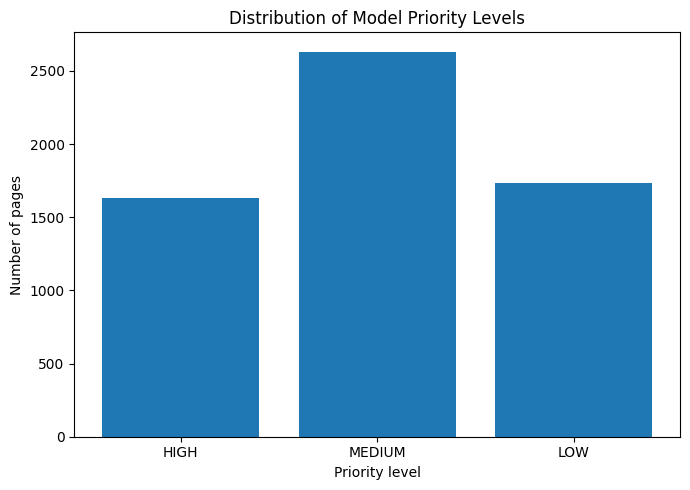


Figure saved:
/content/flyrank-ml-internship-v2/work/outputs/capstone_priority_distribution.png


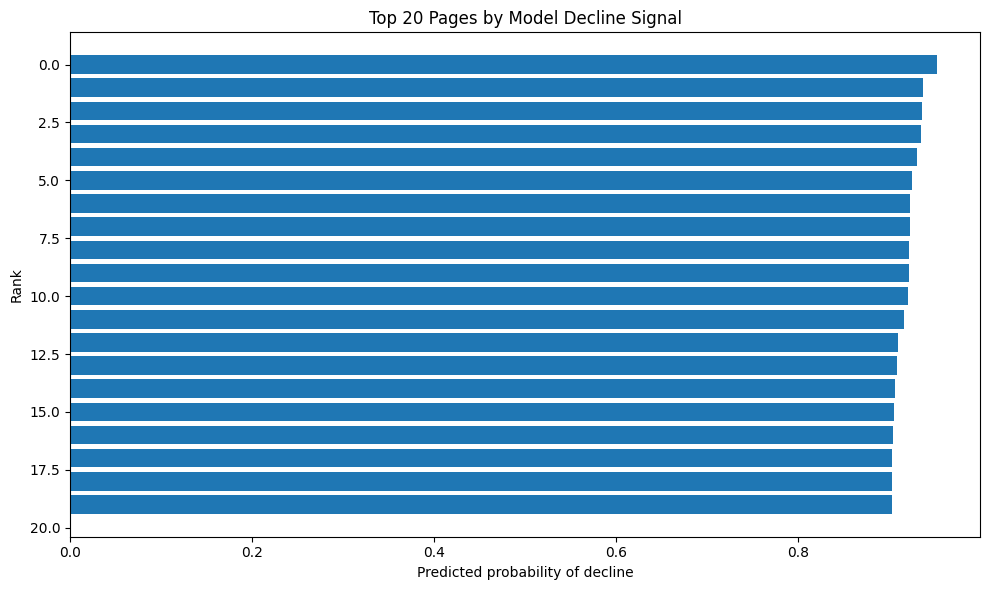


Top-20 figure saved:
/content/flyrank-ml-internship-v2/work/outputs/capstone_top20_decline_signal.png

SECTION 7 COMPLETE
capstone_ranked_recommendations.csv -> True
capstone_priority_distribution.csv -> True
capstone_priority_distribution.png -> True
capstone_top20_decline_signal.png -> True


In [23]:
# ============================================================
# CAPSTONE — SECTION 7: PAPER ARTIFACTS
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# Output directory
OUTPUT_DIR = "/content/flyrank-ml-internship-v2/work/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. Export ranked recommendation table
# ------------------------------------------------------------

table_path = os.path.join(
    OUTPUT_DIR,
    "capstone_ranked_recommendations.csv"
)

recommendation_queue[
    recommendation_columns
].head(20).to_csv(
    table_path,
    index=False
)

print("Ranked recommendation table saved:")
print(table_path)

# ------------------------------------------------------------
# 2. Create priority distribution table
# ------------------------------------------------------------

priority_counts = (
    recommendation_queue["priority_level"]
    .value_counts()
    .reindex(
        ["HIGH", "MEDIUM", "LOW"],
        fill_value=0
    )
    .reset_index()
)

priority_counts.columns = [
    "priority_level",
    "page_count"
]

priority_table_path = os.path.join(
    OUTPUT_DIR,
    "capstone_priority_distribution.csv"
)

priority_counts.to_csv(
    priority_table_path,
    index=False
)

print("\nPriority distribution table saved:")
print(priority_table_path)

display(priority_counts)

# ------------------------------------------------------------
# 3. Create priority distribution figure
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.bar(
    priority_counts["priority_level"],
    priority_counts["page_count"]
)

plt.title("Distribution of Model Priority Levels")
plt.xlabel("Priority level")
plt.ylabel("Number of pages")

plt.tight_layout()

figure_path = os.path.join(
    OUTPUT_DIR,
    "capstone_priority_distribution.png"
)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved:")
print(figure_path)

# ------------------------------------------------------------
# 4. Create top-20 decline signal figure
# ------------------------------------------------------------

top20 = recommendation_queue.head(20).copy()

plt.figure(figsize=(10, 6))

plt.barh(
    range(len(top20)),
    top20["decline_probability"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Pages by Model Decline Signal")
plt.xlabel("Predicted probability of decline")
plt.ylabel("Rank")

plt.tight_layout()

top20_figure_path = os.path.join(
    OUTPUT_DIR,
    "capstone_top20_decline_signal.png"
)

plt.savefig(
    top20_figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nTop-20 figure saved:")
print(top20_figure_path)

# ------------------------------------------------------------
# 5. Final artifact check
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SECTION 7 COMPLETE")
print("=" * 60)

artifacts = [
    table_path,
    priority_table_path,
    figure_path,
    top20_figure_path
]

for artifact in artifacts:
    print(
        os.path.basename(artifact),
        "->",
        os.path.exists(artifact)
    )

### ML-12 — 5-Minute Demo Outline

**0:00–0:45 — Problem**

Explain the research question: which pages should be prioritized for content refresh based on observed search performance and opportunity signals.

**0:45–1:30 — Data**

Introduce the anonymized content-refresh dataset, the declining-page target, and the main categories of features used by the model.

**1:30–2:30 — Methodology**

Explain the binary classification approach, Random Forest model, 38 features, and time-aware 80/20 validation split.

**2:30–3:30 — Results**

Show that the Random Forest measured an F1 score of 0.837, compared with 0.320 for the Week-4 baseline.

**3:30–4:30 — Action Playbook**

Show the ranked recommendation queue and explain how stronger decline signals receive higher review priority.

**4:30–5:00 — Limitations and Takeaway**

Explain that the model supports prioritization and human review. It does not prove that refreshing a page will cause improved performance.

I built a content-refresh prioritization workflow using an anonymized search-performance dataset.

The Random Forest measured an F1 score of 0.837 on a time-aware test split, compared with 0.320 for the Week-4 baseline.

The key takeaway is not that the model guarantees better SEO performance. Instead, it provides a stronger directional signal that can help prioritize pages for human review.

The project connects machine learning validation with a practical content-action playbook while keeping the claims focused on observed results and decision-support.


### Employer-Facing Summary

I built and validated a machine-learning workflow for prioritizing web pages for potential content refresh using anonymized search and content-performance data.

The final Random Forest measured an F1 score of 0.837 under a time-aware validation design, compared with 0.320 for the Week-4 baseline, while passing the final leakage audit.

The resulting ranked action queue turns the model output into a decision-support tool for human review rather than treating predictions as guaranteed outcomes.


## Acknowledgments & Data Credit

This work was completed as part of the FlyRank ML internship. The analysis uses the anonymized dataset and learning materials provided for the internship.

Data and internship information: https://flyrank.ai


## Self-check

Before you submit, confirm each line honestly:

- [X] Every section above is filled — markdown thinking AND the code that backs it
- [X] The notebook runs top to bottom with no errors (Runtime → Run all)
- [X] No client names, URLs, or private queries anywhere
- [X] My claims use careful words: observed, measured, directional, decision-support
- [X] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [X] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [X] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
